**Machine y Deep Learning**

Unidad 2

Práctica 5: Máquinas de Soporte para Regresión (SVR)

*Facilitador: Dr. José Gabriel Rodríguez Rivas*

*Alumna: Carolina Alvarado Hernández*

 Cargar datos y librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#https://drive.google.com/file/d/1LgW2AmS3kPRIKnx_trLVPi_RjsjVjnT_/view?usp=drive_link
file_id = "1LgW2AmS3kPRIKnx_trLVPi_RjsjVjnT_"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)
print(df.head(10))

Mounted at /content/drive
   symboling  normalized-losses         make fuel-type aspiration  \
0          3                122  alfa-romero       gas        std   
1          3                122  alfa-romero       gas        std   
2          1                122  alfa-romero       gas        std   
3          2                164         audi       gas        std   
4          2                164         audi       gas        std   
5          2                122         audi       gas        std   
6          1                158         audi       gas        std   
7          1                122         audi       gas        std   
8          1                158         audi       gas      turbo   
9          2                192          bmw       gas        std   

  num-of-doors   body-style drive-wheels engine-location  wheel-base  ...  \
0          two  convertible          rwd           front        88.6  ...   
1          two  convertible          rwd           front    

Definir variables predictoras y variable objetivo

In [ ]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

Dividir en conjunto de entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 Escalamiento de variables

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

Entrenar modelo SVR

In [ ]:
svr_model = SVR(kernel='rbf', C=100, epsilon=0.2)
# Entrenar el modelo con los datos escalados
svr_model.fit(X_train_scaled, y_train_scaled)

SVR(C=100, epsilon=0.2)

Evaluar el modelo

In [ ]:
# Predecir valores con datos de prueba escalados
y_pred_scaled = svr_model.predict(X_test_scaled)
# Desescala las Predicciones: Usamos el mismo objeto StandardScaler
# para escalar y (el precio) para revertir la escala:
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
# Calcula las métricas comparando las predicciones desescaladas (y_pred)
# con las etiquetas de prueba originales (y_test):
mse_svr = mean_squared_error(y_test, y_pred)
r2_svr = r2_score(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse_svr:.2f}")
print(f"Coeficiente de determinación (R²): {r2_svr:.2f}")

# Calcular el RMSE (mas facil de interpretar que el MSE)
rmse = np.sqrt(mse_svr)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Error cuadrático medio (MSE): 19050289.52
Coeficiente de determinación (R²): 0.84
Raíz del Error cuadrático medio (RMSE): 4364.66


Comparar precios reales vs predichos

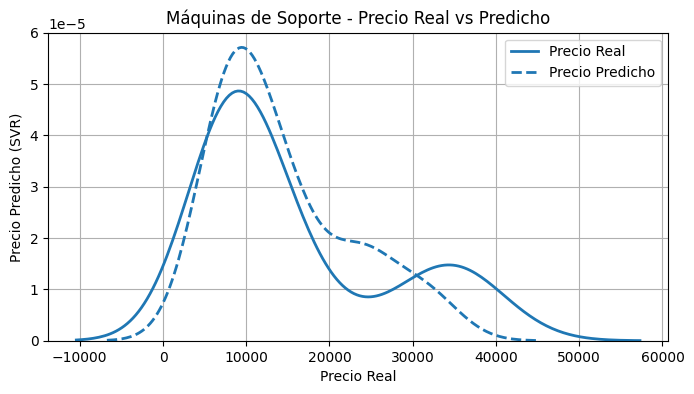

In [ ]:
#plt.scatter(y_test, y_pred, color='purple')
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (SVR)")
plt.title("Máquinas de Soporte - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

Comparar precios con diagrama de dispersión

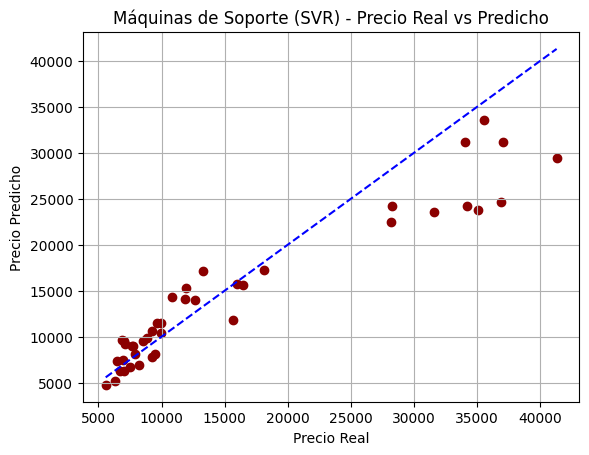

In [ ]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Máquinas de Soporte (SVR) - Precio Real vs Predicho")
plt.grid(True)
plt.show()

Búsqueda de mejores parámetros

In [ ]:
from sklearn.model_selection import GridSearchCV
# Parámetros a probar
param_grid = {
'kernel': ['linear', 'rbf', 'poly'],
'C': [0.1, 1, 10, 100],
'epsilon': [0.01, 0.1, 1],
'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}
# Inicialización y ajuste usando datos escalados
grid_search = GridSearchCV( SVR(), param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train_scaled) # Entrena con datos escalados
# Mejor modelo
best_svr = grid_search.best_estimator_
print("\n Mejores parámetros encontrados:")
print(grid_search.best_params_)
# Predecir valores con datos de prueba escalados
y_pred_scaled = best_svr.predict(X_test_scaled) # Se usa X_test_scaled
# B. Desescala las Predicciones
# La predicción (y_pred_scaled) está en la escala de Y (0 a 1).
# Debemos devolverla a la escala de precio original usando scaler_y.
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
# Calcular métricas (comparando predicción desescalada con y_test original)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\n Resultados del mejor modelo:")
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")
print(f"Raíz del error cuadrático medio (RMSE): {np.sqrt(mse):.2f}")

Fitting 3 folds for each of 180 candidates, totalling 540 fits

 Mejores parámetros encontrados:
{'C': 10, 'epsilon': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}

 Resultados del mejor modelo:
Error cuadrático medio (MSE): 23658789.30
Coeficiente de determinación (R²): 0.81
Raíz del error cuadrático medio (RMSE): 4864.03
